# DBSCAN Clustering

In [1]:
import numpy as np 
from sklearn.cluster import DBSCAN 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings

Demo DBSCAN Clustering 

In [2]:
def createDataPoints(centroidLocation, numSamples, clusterDeviation):
    # Create random data and store in feature matrix X and response vector y.
    X, y = make_blobs(n_samples=numSamples, centers=centroidLocation, 
                                cluster_std=clusterDeviation)
    
    # Standardize features by removing the mean and scaling to unit variance
    X = StandardScaler().fit_transform(X)
    return X, y

In [3]:
X, y = createDataPoints([[4,3], [2,-1], [-1,4]] , 1500, 0.5)

Modeling

In [4]:
epsilon = 0.3
minimumSamples = 7
db = DBSCAN(eps=epsilon, min_samples=minimumSamples).fit(X)
labels = db.labels_
labels

array([0, 1, 1, ..., 1, 1, 2], shape=(1500,))

Disingushing Outliers

In [5]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
core_samples_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(1500,))

In [6]:
# Remove repetition in labels by turning it into a set.
unique_labels = set(labels)
unique_labels

{np.int64(0), np.int64(1), np.int64(2)}

Data visualization

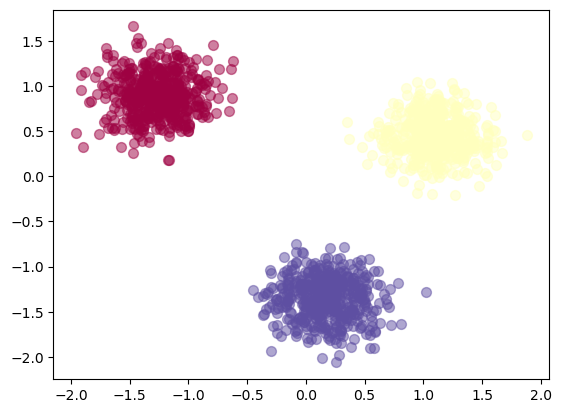

In [8]:
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = 'k'

    class_member_mask = (labels == k)

    # Plot the datapoints that are clustered
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=[col], marker=u'o', alpha=0.5)

    # Plot the outliers
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1],s=50, c=[col], marker=u'o', alpha=0.5)

# Weather Station Clustering using DBSCAN & scikit-learn

In [1]:
import pandas as pd
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/weather-stations20140101-20141231.csv"

df = pd.read_csv(URL)
df.sample(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
694,COLLINS BAY CAMECO,58.183,-103.700,SK,-26.5,11.0,NaN,-8.2,6.0,-38.5,...,6.0,NaN,0.0,5.0,NaN,NaN,NaN,756.7,0.0,4061632
1116,ILE ROUGE,48.069,-69.556,QC,-14.0,0.0,NaN,-3.9,0.0,-24.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,895.6,0.0,7043BP9
224,FERNIE,49.489,-115.073,BC,1.2,7.0,5.0,13.5,7.0,-13.0,...,7.0,NaN,0.0,6.0,NaN,NaN,NaN,353.2,0.0,1152850
641,MACOUN,49.233,-103.233,SK,NaN,NaN,NaN,NaN,NaN,NaN,...,25.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4014870
1194,INUKJUAK,58.472,-78.077,QC,-31.4,0.0,NaN,-17.6,0.0,-41.7,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,1383.7,0.0,7103280


In [2]:
#now we remove the rows that dont have any value in the TM feild

df = df[pd.notnull(df["Tm"])]
df = df.reset_index(drop=True)
df.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573
4,ESQUIMALT HARBOUR,48.432,-123.439,BC,8.8,0.0,NaN,13.1,0.0,1.9,...,8.0,NaN,NaN,12.0,NaN,NaN,NaN,258.6,0.0,1012710


Visualization

c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


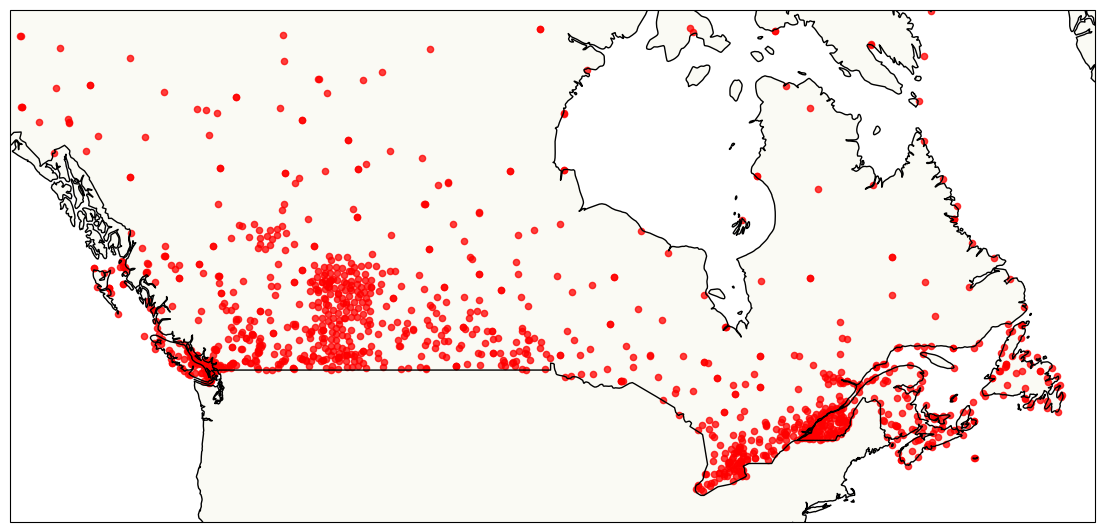

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14,10))
ax = plt.axes(projection=ccrs.Mercator())

# Set bounds
ax.set_extent([-140, -50, 40, 65], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, alpha=0.3)

# Plot points
ax.scatter(df['Long'], df['Lat'],
           color='red',
           s=20,
           alpha=0.75,
           transform=ccrs.PlateCarree())

plt.show()


Clusterning stations based on there locations

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

Clus_dataSet = df[['Long', 'Lat']].values

Clus_dataSet = np.nan_to_num(Clus_dataSet)
Clus_dataSet = StandardScaler().fit_transform(Clus_dataSet)

db = DBSCAN(eps=0.15, min_samples=10).fit(Clus_dataSet)
labels = db.labels_

df["Clus_Db"] = labels

realClusterNum = len(set(labels)) - (1 if -1 in labels else 0)

print("Clusters:", realClusterNum)


Clusters: 4


Visualizing Clusters based on locations

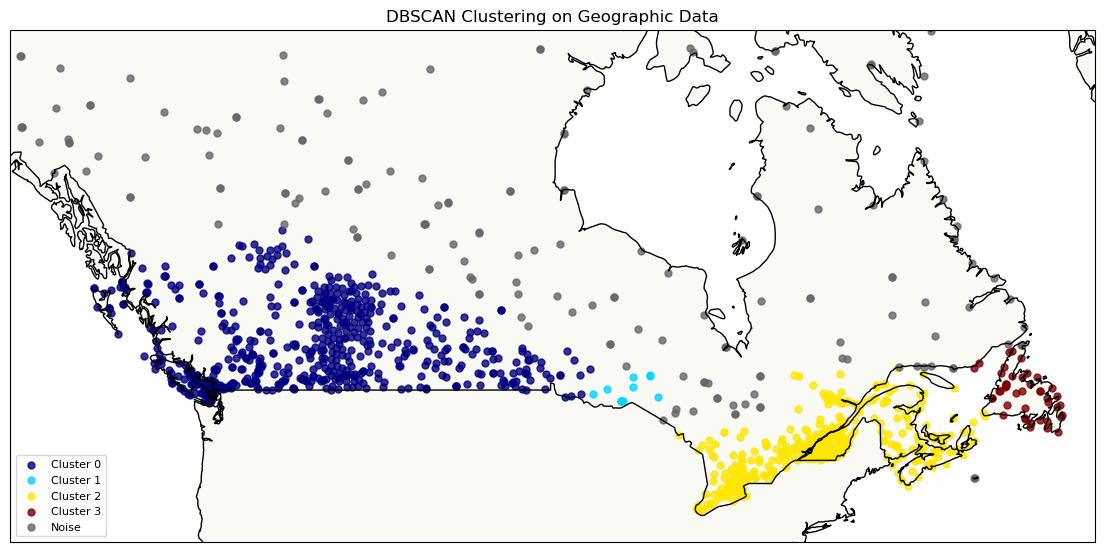

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.Mercator())

ax.set_extent([-140, -50, 40, 65], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, alpha=0.3)

unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

colors = plt.cm.jet(np.linspace(0, 1, max(n_clusters, 1)))

for clust_number in unique_labels:

    cluster_data = df[df["Clus_Db"] == clust_number]

    if clust_number == -1:
        color = [0.4, 0.4, 0.4]
        label_name = "Noise"
    else:
        color = colors[int(clust_number)]
        label_name = f"Cluster {clust_number}"

    ax.scatter(cluster_data["Long"],
               cluster_data["Lat"],
               color=color,
               s=25,
               alpha=0.8,
               transform=ccrs.PlateCarree(),
               label=label_name)

ax.legend(loc="lower left", fontsize=8)

plt.title("DBSCAN Clustering on Geographic Data")
plt.show()


Clustering of stations based on their location, mean, max, and min Temperature

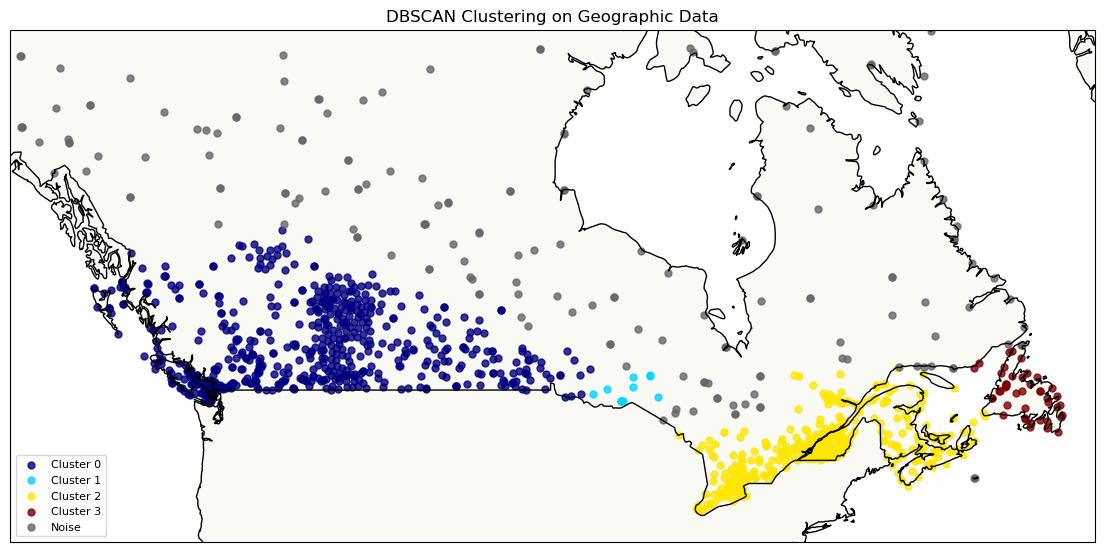

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.Mercator())

ax.set_extent([-140, -50, 40, 65], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, alpha=0.3)

unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

colors = plt.cm.jet(np.linspace(0, 1, max(n_clusters, 1)))

for clust_number in unique_labels:

    cluster_data = df[df["Clus_Db"] == clust_number]

    if clust_number == -1:
        color = [0.4, 0.4, 0.4]
        label_name = "Noise"
    else:
        color = colors[int(clust_number)]
        label_name = f"Cluster {clust_number}"

    ax.scatter(cluster_data["Long"],
               cluster_data["Lat"],
               color=color,
               s=25,
               alpha=0.8,
               transform=ccrs.PlateCarree(),
               label=label_name)

ax.legend(loc="lower left", fontsize=8)

plt.title("DBSCAN Clustering on Geographic Data")
plt.show()


8- Visualization of clusters based on location and Temperture

Clusters found: 4
Cluster 0, Avg Temp: -5.22
Cluster 1, Avg Temp: -21.11
Cluster 2, Avg Temp: -15.31
Cluster 3, Avg Temp: -8.08


c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


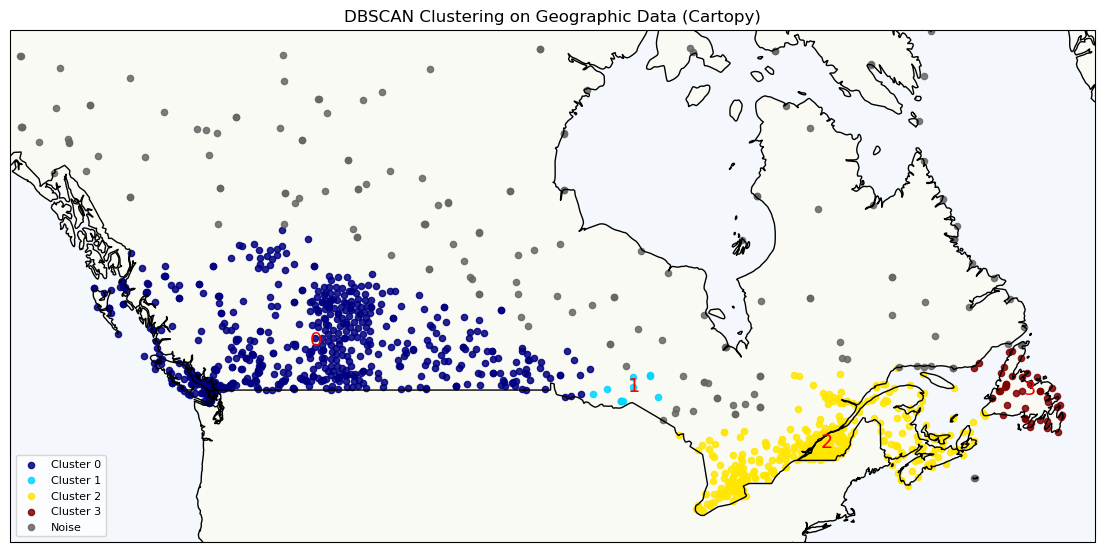

In [ ]:
llon, ulon = -140, -50
llat, ulat = 40, 65


df_clean = df[['Long', 'Lat', 'Tm']].dropna().copy()

coords = df_clean[['Long', 'Lat']].values

coords_scaled = StandardScaler().fit_transform(coords)


db = DBSCAN(eps=0.15, min_samples=10)
labels = db.fit_predict(coords_scaled)

df_clean["Clus_Db"] = labels

real_cluster_num = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters found:", real_cluster_num)


fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.Mercator())

ax.set_extent([llon, ulon, llat, ulat], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.1)

unique_labels = set(labels)
n_clusters = real_cluster_num

colors = plt.cm.jet(np.linspace(0, 1, max(n_clusters, 1)))


for clust_number in unique_labels:

    cluster_data = df_clean[df_clean["Clus_Db"] == clust_number]

    if clust_number == -1:
        color = [0.4, 0.4, 0.4]
        label_name = "Noise"
    else:
        color = colors[int(clust_number)]
        label_name = f"Cluster {clust_number}"

    ax.scatter(cluster_data["Long"],
               cluster_data["Lat"],
               color=color,
               s=20,
               alpha=0.85,
               transform=ccrs.PlateCarree(),
               label=label_name)

    if clust_number != -1 and len(cluster_data) > 0:

        cen_lon = cluster_data["Long"].mean()
        cen_lat = cluster_data["Lat"].mean()

        ax.text(cen_lon, cen_lat,
                str(clust_number),
                fontsize=14,
                color='red',
                transform=ccrs.PlateCarree())

        print(f"Cluster {clust_number}, Avg Temp: {cluster_data['Tm'].mean():.2f}")

ax.legend(loc="lower left", fontsize=8)

plt.title("DBSCAN Clustering on Geographic Data (Cartopy)")
plt.show()